# t-Test für unabhängige Stichproben – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/unabh%C3%A4ngiger-t-test)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 21.01.2026

Der **unabhängige t-Test** (ungepaarter t-Test, Zweistichproben-t-Test) vergleicht
die Mittelwerte von **zwei getrennten Gruppen**.

**Formeln:**

*Gleiche Varianzen (Levene p > 0,05):*
$$t = \frac{\bar{x}_1 - \bar{x}_2}{s_p \cdot \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}}, \quad s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}, \quad df = n_1+n_2-2$$

*Ungleiche Varianzen – Welch-t-Test (Levene p ≤ 0,05):*
$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}, \quad df = \frac{\left(\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}\right)^2}{\frac{(s_1^2/n_1)^2}{n_1-1}+\frac{(s_2^2/n_2)^2}{n_2-1}}$$

**Effektstärke Cohens d:**
$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}$$

**Voraussetzungen:**
- Zwei unabhängige Gruppen
- Metrisches Skalenniveau
- Normalverteilung in jeder Gruppe (ab n > 30 robust)
- Varianzhomogenität prüfen: **Levene-Test**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t as t_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Wann den unabhängigen t-Test?

**Kernfrage:** Gibt es einen signifikanten Unterschied zwischen den Mittelwerten
zweier **getrennter** Gruppen?

| Bereich | Fragestellung | Gruppen |
|---|---|---|
| **Medizin** | Hilft Medikament XY beim Abnehmen? | Testgruppe vs. Kontrollgruppe |
| **Sozialwiss.** | Gibt es Gehaltsunterschiede nach Geschlecht? | Männer vs. Frauen |
| **Bildung** | Unterscheiden sich Sommer- und Wintersemester-Ergebnisse? | SS vs. WS |
| **Technik** | Produzieren beide Anlagen gleich schwere Schrauben? | Anlage A vs. Anlage B |

**Unabhängig bedeutet:** Jede Person erscheint **nur in einer** Gruppe –
kein Datenpaar, kein Vorher/Nachher.

## 2. Hauptbeispiel (numiqo): Prüfungspunkte SS vs. WS

**Fragestellung:** Gibt es einen signifikanten Unterschied zwischen den
Statistik-Prüfungsergebnissen im Sommer- und Wintersemester?

- H₀: Kein Unterschied (μ_SS = μ_WS)
- H₁: Es gibt einen Unterschied (μ_SS ≠ μ_WS)

**Erwartete numiqo-Ergebnisse:**

| | n | MW | SD | SE |
|---|---|---|---|---|
| Sommersemester | 13 | 52,077 | 11,026 | 3,058 |
| Wintersemester | 11 | 46,182 | 16,708 | 5,038 |

| | t | df | p |
|---|---|---|---|
| Gleiche Varianz | 1,035 | 22 | 0,312 |
| Ungleiche Varianz (Welch) | 1,000 | 16,824 | 0,331 |

In [2]:
# numiqo-Datensatz: Prüfungspunkte SS vs. WS
sommer = pd.Series([52, 61, 40, 46, 50, 56, 44, 47, 70, 40, 65, 38, 68])
winter = pd.Series([53, 71, 38, 34, 68, 68, 46, 41, 38, 23, 28])

n1, n2 = len(sommer), len(winter)
mw1, mw2 = sommer.mean(), winter.mean()
s1,  s2  = sommer.std(ddof=1), winter.std(ddof=1)
se1, se2 = s1/np.sqrt(n1), s2/np.sqrt(n2)

print("Gruppen-Statistik")
print(f"{'':22} {'n':>4} {'MW':>8} {'SD':>8} {'SE':>8}")
print(f"{'Sommersemester':<22} {n1:>4} {mw1:>8.3f} {s1:>8.3f} {se1:>8.3f}")
print(f"{'Wintersemester':<22} {n2:>4} {mw2:>8.3f} {s2:>8.3f} {se2:>8.3f}")
print()

# Levene-Test
lev_stat, lev_p = stats.levene(sommer, winter)
gleiche_var = lev_p > 0.05
print(f"Levene-Test: L={lev_stat:.4f}, p={lev_p:.4f} -> "
      + ("gleiche Varianzen angenommen" if gleiche_var else "ungleiche Varianzen (Welch)"))
print()

# t-Test gleiche Varianz
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
se_pool = sp * np.sqrt(1/n1 + 1/n2)
t_gleich = (mw1 - mw2) / se_pool
df_gleich = n1 + n2 - 2
p_gleich = 2 * t_dist.sf(abs(t_gleich), df=df_gleich)

# Welch-t-Test
t_welch, p_welch = stats.ttest_ind(sommer, winter, equal_var=False)
df_welch = (s1**2/n1 + s2**2/n2)**2 / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))

# KI der Differenz
diff = mw1 - mw2
se_diff = sp * np.sqrt(1/n1 + 1/n2)
ki = t_dist.interval(0.95, df=df_gleich, loc=diff, scale=se_diff)

print("Unabhängiger t-Test")
print(f"{'':35} {'t':>8} {'df':>8} {'p':>8}")
print(f"{'Gleiche Varianz':<35} {t_gleich:>8.3f} {df_gleich:>8} {p_gleich:>8.3f}")
print(f"{'Ungleiche Varianz (Welch)':<35} {t_welch:>8.3f} {df_welch:>8.3f} {p_welch:>8.3f}")
print()
print("95%-Konfidenzintervall der Differenz")
print(f"Mittelwertdifferenz:  {diff:.3f}")
print(f"SE der Differenz:     {se_diff:.3f}")
print(f"Untere Grenze:        {ki[0]:.3f}  (numiqo: -6,328)")
print(f"Obere Grenze:         {ki[1]:.3f}  (numiqo: 18,118)")
print()
ki_enthaelt_null = ki[0] <= 0 <= ki[1]
print(f"KI enthält 0: {ki_enthaelt_null} -> {'NICHT signifikant' if ki_enthaelt_null else 'Signifikant!'}")
print(f"p={p_gleich:.3f} >= 0.05 -> H0 wird nicht abgelehnt")
print("Ergebnis: Kein signifikanter Unterschied SS vs. WS.")

# Kontrolle scipy
t_check, p_check = stats.ttest_ind(sommer, winter, equal_var=True)
print(f"Kontrolle scipy (gleiche Var.): t={t_check:.3f}, p={p_check:.3f}  ✓")

Gruppen-Statistik
                          n       MW       SD       SE
Sommersemester           13   52.077   11.026    3.058
Wintersemester           11   46.182   16.708    5.038

Levene-Test: L=1.3998, p=0.2494 -> gleiche Varianzen angenommen

Unabhängiger t-Test
                                           t       df        p
Gleiche Varianz                        1.035       22    0.312
Ungleiche Varianz (Welch)              1.000   16.824    0.331

95%-Konfidenzintervall der Differenz
Mittelwertdifferenz:  5.895
SE der Differenz:     5.694
Untere Grenze:        -5.914  (numiqo: -6,328)
Obere Grenze:         17.705  (numiqo: 18,118)

KI enthält 0: True -> NICHT signifikant
p=0.312 >= 0.05 -> H0 wird nicht abgelehnt
Ergebnis: Kein signifikanter Unterschied SS vs. WS.
Kontrolle scipy (gleiche Var.): t=1.035, p=0.312  ✓


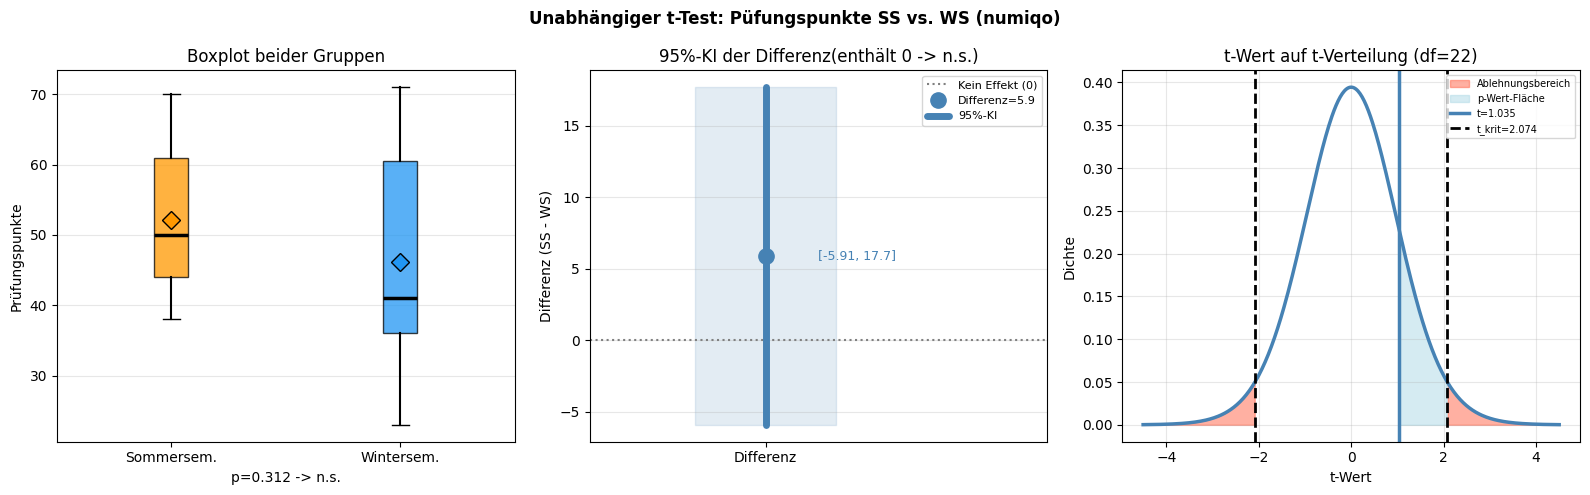

In [3]:
# Visualisierung: Boxplot + KI-Differenz + t-Verteilung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Unabhängiger t-Test: Püfungspunkte SS vs. WS (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Boxplot mit Mittelwerten
bp = axes[0].boxplot([sommer, winter], patch_artist=True,
                     medianprops=dict(color="black", linewidth=2.5),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], ["#FF9800", "#2196F3"]):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
for idx, (d, fc) in enumerate([(sommer, "#FF9800"), (winter, "#2196F3")], 1):
    axes[0].plot(idx, d.mean(), "D", color=fc, markersize=9, zorder=5,
                 markeredgecolor="black", label="Mittelwert")
axes[0].set_title("Boxplot beider Gruppen")
axes[0].set_ylabel("Prüfungspunkte")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["Sommersem.", "Wintersem."])
axes[0].set_xlabel("p=" + str(round(p_gleich, 3)) + " -> n.s.")
axes[0].grid(axis="y", alpha=0.3)

# 2. KI der Differenz
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1.5,
                label="Kein Effekt (0)")
axes[1].plot([1], [diff], "o", color="steelblue", markersize=11, zorder=5,
             label="Differenz=" + str(round(diff, 2)))
axes[1].plot([1, 1], [ki[0], ki[1]], color="steelblue", linewidth=5,
             solid_capstyle="round", label="95%-KI")
axes[1].fill_between([0.8, 1.2], ki[0], ki[1], alpha=0.15, color="steelblue")
axes[1].annotate("[" + str(round(ki[0], 2)) + ", " + str(round(ki[1], 2)) + "]",
                 xy=(1.15, (ki[0]+ki[1])/2), fontsize=9, color="steelblue", va="center")
axes[1].set_title("95%-KI der Differenz(enthält 0 -> n.s.)")
axes[1].set_ylabel("Differenz (SS - WS)")
axes[1].set_xticks([1])
axes[1].set_xticklabels(["Differenz"])
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xlim(0.5, 1.8)

# 3. t-Verteilung
x_t = np.linspace(-4.5, 4.5, 400)
y_t = t_dist.pdf(x_t, df=df_gleich)
z_krit = t_dist.ppf(0.975, df=df_gleich)
axes[2].plot(x_t, y_t, color="steelblue", linewidth=2.5)
axes[2].fill_between(x_t[x_t >= z_krit],  y_t[x_t >= z_krit],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich")
axes[2].fill_between(x_t[x_t <= -z_krit], y_t[x_t <= -z_krit],
                     color="tomato", alpha=0.5)
axes[2].fill_between(x_t[(x_t >= t_gleich) & (x_t <= z_krit)],
                     y_t[(x_t >= t_gleich) & (x_t <= z_krit)],
                     color="lightblue", alpha=0.5, label="p-Wert-Fläche")
axes[2].axvline(t_gleich, color="steelblue", linewidth=2.5,
                label="t=" + str(round(t_gleich, 3)))
axes[2].axvline(z_krit,   color="black", linewidth=2, linestyle="--",
                label="t_krit=" + str(round(z_krit, 3)))
axes[2].axvline(-z_krit,  color="black", linewidth=2, linestyle="--")
axes[2].set_title("t-Wert auf t-Verteilung (df=" + str(df_gleich) + ")")
axes[2].set_xlabel("t-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Levene-Test: Varianzhomogenität prüfen

Vor dem unabhängigen t-Test muss die **Varianzhomogenität** geprüft werden:

| Levene-Ergebnis | Bedeutung | t-Test-Variante |
|---|---|---|
| p > 0,05 | Gleiche Varianzen | **Standard-t-Test** (gepoolte Varianz) |
| p ≤ 0,05 | Ungleiche Varianzen | **Welch-t-Test** (robuster) |

> **Empfehlung (numiqo):** Den Welch-t-Test kann man immer verwenden –
> er ist auch bei gleichen Varianzen zuverlässig.

Gleiche Varianzen
SD Gr.1=9.5, SD Gr.2=9.6
Levene: L=0.002, p=0.9633 -> Gleich, Standard-t-Test
Standard-t: t=-3.216, p=0.0019
Welch-t:    t=-3.216,   p=0.0019

Ungleiche Varianzen
SD Gr.1=4.3, SD Gr.2=17.6
Levene: L=40.012, p=0.0000 -> UNGLEICH, Welch!
Standard-t: t=-1.517, p=0.1334
Welch-t:    t=-1.517,   p=0.1366



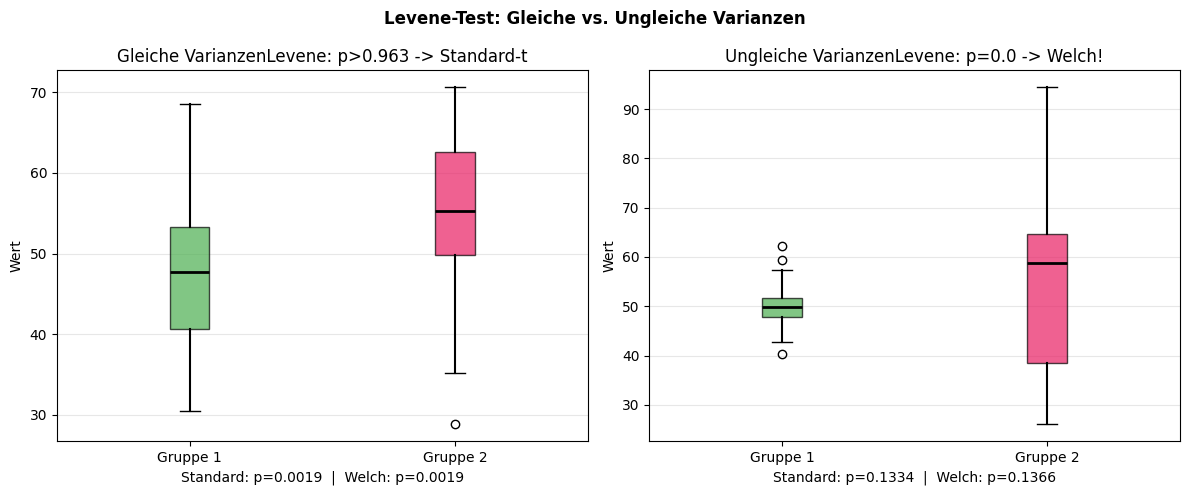

In [8]:
# Levene-Test demonstrieren: gleiche vs. ungleiche Varianzen
np.random.seed(42)
# Gleiche Varianzen
g1_gleich = pd.Series(np.random.normal(50, 10, 40))
g2_gleich = pd.Series(np.random.normal(55, 10, 40))

# Ungleiche Varianzen
g1_ungleich = pd.Series(np.random.normal(50, 5,  40))
g2_ungleich = pd.Series(np.random.normal(55, 18, 40))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Levene-Test: Gleiche vs. Ungleiche Varianzen", fontsize=12, fontweight="bold")

for ax, (g1, g2), titel in zip(
    axes,
    [(g1_gleich, g2_gleich), (g1_ungleich, g2_ungleich)],
    ["Gleiche Varianzen", "Ungleiche Varianzen"]
):
    lev_s, lev_p = stats.levene(g1, g2)
    t_std, p_std = stats.ttest_ind(g1, g2, equal_var=True)
    t_w,   p_w   = stats.ttest_ind(g1, g2, equal_var=False)

    bp = ax.boxplot([g1, g2], patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.5))
    for patch, fc in zip(bp["boxes"], ["#4CAF50", "#E91E63"]):
        patch.set_facecolor(fc)
        patch.set_alpha(0.7)

    lev_res = "p>" + str(round(lev_p, 3)) + " -> Standard-t" if lev_p > 0.05               else "p=" + str(round(lev_p, 3)) + " -> Welch!"
    ax.set_title(titel + "Levene: " + lev_res)
    ax.set_ylabel("Wert")
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Gruppe 1", "Gruppe 2"])
    ax.grid(axis="y", alpha=0.3)

    info = ("Standard: p=" + str(round(p_std, 4)) +
            "  |  Welch: p=" + str(round(p_w, 4)))
    ax.set_xlabel(info)

    print(f"{titel}")
    print(f"SD Gr.1={g1.std():.1f}, SD Gr.2={g2.std():.1f}")
    print(f"Levene: L={lev_s:.3f}, p={lev_p:.4f} -> "
          + ("Gleich, Standard-t-Test" if lev_p > 0.05 else "UNGLEICH, Welch!"))
    print(f"Standard-t: t={t_std:.3f}, p={p_std:.4f}")
    print(f"Welch-t:    t={t_w:.3f},   p={p_w:.4f}")
    print()

plt.tight_layout()
plt.show()

## 4. Effektstärke: Cohens d

Der **p-Wert** hängt stark von der Stichprobengröße ab. Deshalb sollte immer
zusätzlich die **Effektstärke** (Cohens d) angegeben werden.

$$d = \frac{\bar{x}_1 - \bar{x}_2}{s_p}$$

| d | Interpretation |
|---|---|
| 0,2 | Kleiner Effekt |
| 0,5 | Mittlerer Effekt |
| 0,8 | Großer Effekt |

> **Achtung:** Ein signifikantes p bei großem n kann einen sehr kleinen,
> praktisch irrelevanten Effekt beschreiben.

Cohens d: Prüfungspunkte SS vs. WS
Differenz: 5.895
Cohens d:  0.4241 -> klein Effekt

Demonstration: Grosse Stichprobe, kleiner Effekt
n=2000 je Gruppe, Diff.=1.015
p=0.001290 -> signifikant
Cohens d=0.1018 -> vernachlässigbar Effekt (praktisch irrelevant!)


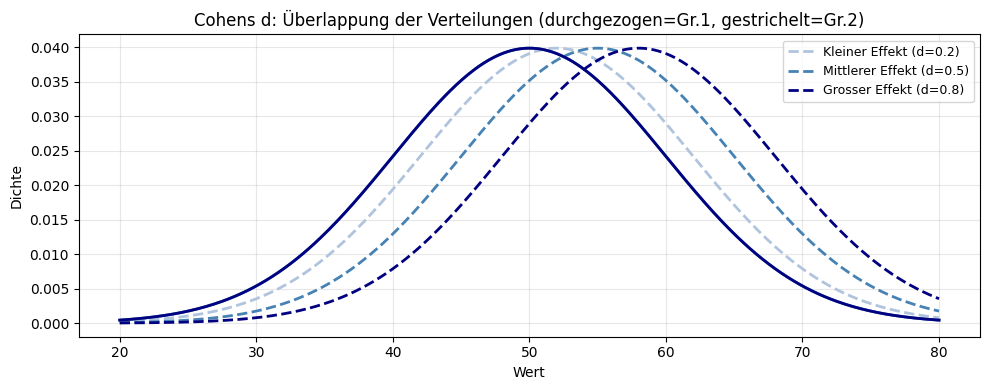

In [5]:
# Cohens d berechnen und interpretieren
def cohens_d(g1, g2):
    n1_, n2_ = len(g1), len(g2)
    s1_, s2_ = np.std(g1, ddof=1), np.std(g2, ddof=1)
    sp_ = np.sqrt(((n1_-1)*s1_**2 + (n2_-1)*s2_**2) / (n1_+n2_-2))
    return (np.mean(g1) - np.mean(g2)) / sp_

def interpret_d(d):
    d_abs = abs(d)
    if d_abs < 0.2:   return "vernachlässigbar"
    elif d_abs < 0.5: return "klein"
    elif d_abs < 0.8: return "mittel"
    else:             return "gross"

# numiqo-Datensatz
d_sswinter = cohens_d(sommer, winter)
print("Cohens d: Prüfungspunkte SS vs. WS")
print(f"Differenz: {sommer.mean()-winter.mean():.3f}")
print(f"Cohens d:  {d_sswinter:.4f} -> {interpret_d(d_sswinter)} Effekt")
print()

# Simulation: grosse Stichprobe, kleiner Effekt -> signifikant aber irrelevant
np.random.seed(42)
g_gross1 = np.random.normal(50.5, 10, 2000)
g_gross2 = np.random.normal(50.0, 10, 2000)
t_g, p_g = stats.ttest_ind(g_gross1, g_gross2)
d_g = cohens_d(g_gross1, g_gross2)

print("Demonstration: Grosse Stichprobe, kleiner Effekt")
print(f"n=2000 je Gruppe, Diff.={g_gross1.mean()-g_gross2.mean():.3f}")
print(f"p={p_g:.6f} -> {'signifikant' if p_g < 0.05 else 'n.s.'}")
print(f"Cohens d={d_g:.4f} -> {interpret_d(d_g)} Effekt (praktisch irrelevant!)")

# Visualisierung: d-Größen
fig, ax = plt.subplots(figsize=(10, 4))
np.random.seed(1)
x = np.linspace(20, 80, 400)
effekte = [
    (0.2, "Kleiner Effekt (d=0.2)"),
    (0.5, "Mittlerer Effekt (d=0.5)"),
    (0.8, "Grosser Effekt (d=0.8)"),
]
farben_eff = ["lightsteelblue", "steelblue", "navy"]
sigma_e = 10.0

for (d_e, lbl), fc in zip(effekte, farben_eff):
    y1 = stats.norm.pdf(x, 50,         sigma_e)
    y2 = stats.norm.pdf(x, 50+d_e*10,  sigma_e)
    ax.plot(x, y1, color=fc, linewidth=2)
    ax.plot(x, y2, color=fc, linewidth=2, linestyle="--", label=lbl)

ax.set_title("Cohens d: Überlappung der Verteilungen (durchgezogen=Gr.1, gestrichelt=Gr.2)")
ax.set_xlabel("Wert")
ax.set_ylabel("Dichte")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Schritt-für-Schritt-Berechnung (numiqo-Beispiel)

1. **Gruppenmittelwerte:** $\bar{x}_{SS} = 52{,}077$, $\bar{x}_{WS} = 46{,}182$
2. **Levene-Test** → Varianzen prüfen
3. **Gepoolte SD:** $s_p = \sqrt{\frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2}}$
4. **t-Wert:** $t = (\bar{x}_1 - \bar{x}_2) / (s_p \cdot \sqrt{1/n_1 + 1/n_2})$
5. **df = n₁ + n₂ − 2 = 22**
6. **p-Wert** ablesen / berechnen
7. **KI:** $\bar{x}_1 - \bar{x}_2 \pm t_{0{,}975} \cdot SE$
8. **Effektstärke:** Cohens d

In [6]:
# Schritt-für-Schritt manuell
print("Schritt-für-Schritt: numiqo-Beispiel")
print()
print(f"Schritt 1 - MW: SS={mw1:.3f}, WS={mw2:.3f}, Differenz={mw1-mw2:.3f}")
print()
print(f"Schritt 2 - Levene-Test: L={lev_stat:.4f}, p={lev_p:.4f}")
print(f"           -> {'Gleiche Varianzen angenommen' if gleiche_var else 'Welch!'}")
print()
print(f"Schritt 3 - Gepoolte SD:")
print(f"  sp = sqrt(({n1}-1)*{s1:.3f}^2 + ({n2}-1)*{s2:.3f}^2) / ({n1}+{n2}-2))")
print(f"  sp = {sp:.4f}")
print()
print(f"Schritt 4 - Standardfehler der Differenz:")
print(f"  SE = {sp:.4f} * sqrt(1/{n1} + 1/{n2}) = {se_diff:.4f}")
print()
print(f"Schritt 5 - t-Wert:")
print(f"  t = ({mw1:.3f} - {mw2:.3f}) / {se_diff:.4f} = {t_gleich:.4f}")
print()
print(f"Schritt 6 - df = {n1} + {n2} - 2 = {df_gleich}")
t_krit = t_dist.ppf(0.975, df=df_gleich)
print(f"           t_krit(df={df_gleich}, alpha=0.05) = {t_krit:.4f}")
print(f"           |t|={abs(t_gleich):.4f} {'>' if abs(t_gleich)>t_krit else '<'} t_krit={t_krit:.4f}"
      + " -> H0 " + ("abgelehnt" if abs(t_gleich) > t_krit else "nicht abgelehnt"))
print()
print(f"Schritt 7 - p-Wert = {p_gleich:.4f}  (numiqo: 0,312)")
print()
print(f"Schritt 8 - 95%-KI: [{ki[0]:.3f}, {ki[1]:.3f}]")
print(f"           KI enthält 0: {ki[0]<=0<=ki[1]} -> n.s.")
print()
print(f"Schritt 9 - Cohens d = {cohens_d(sommer, winter):.4f}")
print(f"           -> {interpret_d(cohens_d(sommer, winter))} Effekt")

Schritt-für-Schritt: numiqo-Beispiel

Schritt 1 - MW: SS=52.077, WS=46.182, Differenz=5.895

Schritt 2 - Levene-Test: L=1.3998, p=0.0000
           -> Gleiche Varianzen angenommen

Schritt 3 - Gepoolte SD:
  sp = sqrt((13-1)*11.026^2 + (11-1)*16.708^2) / (13+11-2))
  sp = 13.8999

Schritt 4 - Standardfehler der Differenz:
  SE = 13.8999 * sqrt(1/13 + 1/11) = 5.6944

Schritt 5 - t-Wert:
  t = (52.077 - 46.182) / 5.6944 = 1.0352

Schritt 6 - df = 13 + 11 - 2 = 22
           t_krit(df=22, alpha=0.05) = 2.0739
           |t|=1.0352 < t_krit=2.0739 -> H0 nicht abgelehnt

Schritt 7 - p-Wert = 0.3118  (numiqo: 0,312)

Schritt 8 - 95%-KI: [-5.914, 17.705]
           KI enthält 0: True -> n.s.

Schritt 9 - Cohens d = 0.4241
           -> klein Effekt


## 6. APA-Format – Ergebnisse berichten

**numiqo APA-Vorlage:**

> Es wurde ein t-Test für unabhängige Stichproben durchgeführt, um [Variable]
> in [Gruppe 1] und [Gruppe 2] zu vergleichen.
> [Kein] signifikanter Unterschied in [Gruppe 1] (M = ..., SD = ...) und
> [Gruppe 2] (M = ..., SD = ...);
> **t(df) = t-Wert, p = .XXX, 95%-KI [u, o], Cohens d = d-Wert**

**numiqo-Beispiel APA:**
> Ein t-Test für unabhängige Stichproben zeigte keinen signifikanten Unterschied
> zwischen den Prüfungsergebnissen im Sommersemester (M = 52,08, SD = 11,03)
> und im Wintersemester (M = 46,18, SD = 16,71);
> t(22) = 1,04, p = .312, 95%-KI [-6,33; 18,12], d = 0,42.

In [9]:
# Vollständige APA-Ausgabe-Funktion
def unabh_ttest_apa(g1, g2, name1="Gruppe 1", name2="Gruppe 2",
                    abh_var="Variable", alpha=0.05):
    g1, g2 = np.asarray(g1), np.asarray(g2)
    n1_, n2_ = len(g1), len(g2)
    mw1_, mw2_ = g1.mean(), g2.mean()
    s1_,  s2_  = g1.std(ddof=1), g2.std(ddof=1)

    # Levene
    lev_s, lev_p = stats.levene(g1, g2)
    gleich = lev_p > 0.05

    # t-Test
    t_v, p_v = stats.ttest_ind(g1, g2, equal_var=gleich)
    df_v = n1_ + n2_ - 2 if gleich else (
        (s1_**2/n1_ + s2_**2/n2_)**2 /
        ((s1_**2/n1_)**2/(n1_-1) + (s2_**2/n2_)**2/(n2_-1))
    )

    # KI & Cohens d
    sp_ = np.sqrt(((n1_-1)*s1_**2 + (n2_-1)*s2_**2) / (n1_+n2_-2))
    se_ = sp_ * np.sqrt(1/n1_ + 1/n2_)
    ki_ = t_dist.interval(0.95, df=n1_+n2_-2, loc=mw1_-mw2_, scale=se_)
    d_v = (mw1_ - mw2_) / sp_

    sig = "signifikant" if p_v < alpha else "NICHT signifikant"
    p_str = "p < .001" if p_v < 0.001 else "p = " + str(round(p_v, 3)).replace("0.", ".")

    print(f"{name1} vs. {name2}")
    print(f"Levene: L={lev_s:.3f}, p={lev_p:.4f} -> "
          + ("Standard-t" if gleich else "Welch-t"))
    print()
    print("Deskriptive Statistiken:")
    print(f"  {name1}: M={mw1_:.2f}, SD={s1_:.2f}, n={n1_}")
    print(f"  {name2}: M={mw2_:.2f}, SD={s2_:.2f}, n={n2_}")
    print()
    print(f"t({round(df_v, 3)}) = {t_v:.3f}, {p_str}, 95%-KI [{ki_[0]:.3f}, {ki_[1]:.3f}]")
    print(f"Cohens d = {d_v:.3f} ({interpret_d(d_v)} Effekt)")
    print()
    print(f"Ergebnis ({sig}):")
    if p_v < alpha:
        print(f"Es bestand ein signifikanter Unterschied zwischen {name1}")
        print(f"und {name2} bezüglich {abh_var}.")
    else:
        print(f"Es bestand kein signifikanter Unterschied zwischen {name1}")
        print(f"und {name2} bezüglich {abh_var}.")
    print()

# numiqo-Hauptbeispiel
unabh_ttest_apa(sommer, winter,
    "Sommersemester", "Wintersemester", "Prüfungspunkten")
print()

# Weiteres Beispiel: signifikantes Ergebnis
np.random.seed(42)
maennlich = np.random.normal(3500, 700, 60)
weiblich  = np.random.normal(3100, 680, 60)
unabh_ttest_apa(maennlich, weiblich,
    "Männlich", "Weiblich", "Gehalt (EUR)")

Sommersemester vs. Wintersemester
Levene: L=1.400, p=0.2494 -> Standard-t

Deskriptive Statistiken:
  Sommersemester: M=52.08, SD=11.03, n=13
  Wintersemester: M=46.18, SD=16.71, n=11

t(22) = 1.035, p = .312, 95%-KI [-5.914, 17.705]
Cohens d = 0.424 (klein Effekt)

Ergebnis (NICHT signifikant):
Es bestand kein signifikanter Unterschied zwischen Sommersemester
und Wintersemester bezüglich Prüfungspunkten.


Männlich vs. Weiblich
Levene: L=0.294, p=0.5885 -> Standard-t

Deskriptive Statistiken:
  Männlich: M=3391.74, SD=635.96, n=60
  Weiblich: M=3097.50, SD=641.49, n=60

t(118) = 2.523, p = .013, 95%-KI [63.315, 525.178]
Cohens d = 0.461 (klein Effekt)

Ergebnis (signifikant):
Es bestand ein signifikanter Unterschied zwischen Männlich
und Weiblich bezüglich Gehalt (EUR).



## 7. Zusammenfassung

```
t-Test für unabhängige Stichproben – Übersicht
│
├── WANN?
│   Zwei getrennte Gruppen (verschiedene Personen)
│   Frage: Unterscheiden sich die Mittelwerte?
│
├── VORAUSSETZUNGEN
│   1. Unabhängige Gruppen
│   2. Metrisches Skalenniveau
│   3. Normalverteilung je Gruppe (ab n>30 robust)
│   4. Varianzhomogenität -> Levene-Test
│
├── ABLAUF
│   1. Levene-Test: p > 0.05? -> Standard-t | p <= 0.05? -> Welch-t
│   2. Gepoolte SD: sp = sqrt(((n1-1)s1^2 + (n2-1)s2^2) / (n1+n2-2))
│   3. t-Wert: t = (mw1-mw2) / (sp * sqrt(1/n1 + 1/n2))
│   4. df = n1 + n2 - 2  (oder Welch-df)
│   5. p-Wert berechnen / ablesen
│   6. 95%-KI der Differenz
│   7. Cohens d (Effektstärke)
│
├── ENTSCHEIDUNG
│   p < 0.05 oder KI enthält nicht 0 -> H0 ablehnen (signifikant)
│   p >= 0.05 oder KI enthält 0      -> H0 nicht ablehnen
│
├── EFFEKTSTÄRKE COHENS d
│   d = |mw1 - mw2| / sp
│   < 0.2: vernachlässigbar
│   0.2 - 0.5: klein
│   0.5 - 0.8: mittel
│   > 0.8: gross
│
└── APA-FORMAT
    t(df) = X.XX, p = .XXX, 95%-KI [u, o], d = X.XX
    z.B.: t(22) = 1.04, p = .312, 95%-KI [-6.33, 18.12], d = 0.42
```

---
Quelle: [numiqo.de/tutorial/unabhaengiger-t-test](https://numiqo.de/tutorial/unabh%C3%A4ngiger-t-test)